# Breast Cancer Classification using CNN-LSTM with Grey Wolf Optimization

This notebook implements a hybrid deep learning model that combines:
- Convolutional Neural Networks (CNN)
- Long Short-Term Memory Networks (LSTM)
- Grey Wolf Optimizer (GWO) for hyperparameter optimization

## Project Overview
The model classifies breast cancer cases into healthy and sick categories using medical data from both left and right breast examinations.

## Required Libraries
First, let's import all the necessary libraries for our implementation.

In [1]:
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
import functools
import matplotlib.pyplot as plt


## 1. Data Loading and Preparation
Loading the .mat files containing breast examination data and preparing the datasets for training.

In [2]:
# --- 1) Loading and preparing the data ---
FLH = loadmat("myenvLH.mat")['FLH']
FLS = loadmat("myenvLS.mat")['FLS']
FRH = loadmat("myenvRH.mat")['FRH']
FRS = loadmat("myenvRS.mat")['FRS']

healthy = np.hstack((FLH, FRH))
sick = np.hstack((FRS, FLS))
h_lab = np.ones((healthy.shape[0], 1))
s_lab = np.zeros((sick.shape[0], 1))
data = np.vstack((np.hstack((healthy, h_lab)),
                 np.hstack((sick, s_lab))))

X = data[:, :-1]
y = data[:, -1]

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42, shuffle=True
)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

## 2. Search Space Definition
Define the boundaries for the Grey Wolf Optimizer search space. We have 9 dimensions to optimize:

In [3]:
# --- 2) Search space after removing conv2 and n_conv (9 dimensions) ---
# [conv_filters, kernel_size,
#  lstm_units, dropout_rate, learning_rate,
#  batch_size, n_dense, dense_units, epochs]
lb = np.array([16, 2, 10, 0.0, 1e-4, 16, 1, 16, 5])
ub = np.array([128, 5, 200, 0.7, 1e-2, 128, 3, 256, 30])
dims = lb.size

## 3. Model Architecture and Fitness Function
Implementation of the CNN-LSTM model builder and the fitness function with caching for optimization.

In [4]:
# --- 3) Simplified model builder and fitness function with caching ---
def create_model(conv_f, k_size, lstm_u, drop_r, lr, n_dense, dense_u):
    m = tf.keras.Sequential()
    # Single Conv1D layer
    m.add(tf.keras.layers.Input(shape=(X_train.shape[1], 1)))
    m.add(tf.keras.layers.Conv1D(
        filters=conv_f,
        kernel_size=k_size,
        padding='same',
        activation='relu'
    ))
    m.add(tf.keras.layers.BatchNormalization())
    m.add(tf.keras.layers.MaxPooling1D(pool_size=2))
    m.add(tf.keras.layers.Dropout(drop_r))
    # LSTM layer
    m.add(tf.keras.layers.LSTM(lstm_u))
    m.add(tf.keras.layers.Dropout(drop_r))
    # Variable number of Dense layers
    for _ in range(n_dense):
        m.add(tf.keras.layers.Dense(dense_u, activation='relu'))
        m.add(tf.keras.layers.Dropout(drop_r))
    # Output layer
    m.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return m

# Cache fitness function to avoid re-evaluating same inputs
fitness_cache = {}
def fitness_function(position):
    # Convert wolf position to tuple for caching
    position_tuple = tuple(position.round(6))
    
    # If this position was evaluated before, use cached value
    if position_tuple in fitness_cache:
        return fitness_cache[position_tuple]
    
    # clip within bounds and decode
    pos = np.minimum(np.maximum(position, lb), ub)
    conv_f, k_size = int(pos[0]), int(pos[1])
    lstm_u, drop_r = int(pos[2]), float(pos[3])
    lr, bs = float(pos[4]), int(pos[5])
    n_dense, dense_u, epochs_h = int(pos[6]), int(pos[7]), int(pos[8])

    model = create_model(conv_f, k_size, lstm_u, drop_r, lr, n_dense, dense_u)
    
    # Add Early Stopping to prevent overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )
    
    # Use validation_data during training
    history = model.fit(
        X_train, y_train, 
        epochs=epochs_h, 
        batch_size=bs, 
        verbose=0,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping]
    )
    
    # Evaluate model on validation data
    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    
    # Cache the result
    fitness_cache[position_tuple] = -acc
    
    return -acc  # minimize negative accuracy


## 4. Grey Wolf Optimizer Implementation
Implementation of the GWO algorithm with improvements for hyperparameter optimization.

In [5]:
# --- 4) GWO functions with improvements ---
def initialize_population(pop_size, dim):
    return np.random.uniform(lb, ub, (pop_size, dim))

def evaluate_population(pop):
    return np.array([fitness_function(ind) for ind in pop])

def update_position(pos, alpha, beta, delta, a):
    new = np.zeros_like(pos)
    for d in range(dims):
        r1, r2 = np.random.rand(), np.random.rand()
        A1, C1 = 2*a*r1 - a, 2*r2
        D1 = abs(C1*alpha[d] - pos[d]); X1 = alpha[d] - A1*D1

        r1, r2 = np.random.rand(), np.random.rand()
        A2, C2 = 2*a*r1 - a, 2*r2
        D2 = abs(C2*beta[d] - pos[d]); X2 = beta[d] - A2*D2

        r1, r2 = np.random.rand(), np.random.rand()
        A3, C3 = 2*a*r1 - a, 2*r2
        D3 = abs(C3*delta[d] - pos[d]); X3 = delta[d] - A3*D3

        new[d] = (X1 + X2 + X3) / 3
    return np.clip(new, lb, ub)

def grey_wolf_optimizer(epochs, pop_size):
    pop = initialize_population(pop_size, dims)
    fits = evaluate_population(pop)
    idx = np.argsort(fits)
    alpha, beta, delta = pop[idx[0]], pop[idx[1]], pop[idx[2]]
    best_fit_glob = fits[idx[0]]
    best_pos_glob = alpha.copy()
    
    # Store optimization progress for later visualization
    history = {
        'best_fitness': [-best_fit_glob],  # Convert to accuracy instead of error
        'iterations': [0]
    }

    for t in range(epochs):
        a = 2 - 2*(t/epochs)
        for i in range(pop_size):
            pop[i] = update_position(pop[i], alpha, beta, delta, a)
        fits = evaluate_population(pop)
        idx = np.argsort(fits)
        alpha, beta, delta = pop[idx[0]], pop[idx[1]], pop[idx[2]]
        if fits[idx[0]] < best_fit_glob:
            best_fit_glob = fits[idx[0]]
            best_pos_glob = alpha.copy()
            
        history['best_fitness'].append(-best_fit_glob)  # Convert to accuracy
        history['iterations'].append(t+1)
        
        print(f"Iteration {t+1}/{epochs}, Best fit so far = {-best_fit_glob:.4f}")
    return best_pos_glob, best_fit_glob, history


## 5. Running the Optimization
Execute the GWO algorithm with increased population size and iterations.

In [6]:
# --- 5) Run GWO with increased population size and iterations ---
best_pos, best_fit, history = grey_wolf_optimizer(epochs=20, pop_size=10)
best_acc = -best_fit

print("\nBest validation accuracy:", best_acc)
print("Best hyperparameters:")
print(" conv_filters =", int(best_pos[0]))
print(" kernel_size  =", int(best_pos[1]))
print(" lstm_units   =", int(best_pos[2]))
print(" dropout_rate =", best_pos[3])
print(" learning_rate=", best_pos[4])
print(" batch_size   =", int(best_pos[5]))
print(" n_dense      =", int(best_pos[6]))
print(" dense_units  =", int(best_pos[7]))
print(" epochs       =", int(best_pos[8]))

Iteration 1/20, Best fit so far = 0.8947
Iteration 2/20, Best fit so far = 0.9211
Iteration 3/20, Best fit so far = 0.9474
Iteration 4/20, Best fit so far = 0.9474
Iteration 5/20, Best fit so far = 0.9474
Iteration 6/20, Best fit so far = 0.9474
Iteration 7/20, Best fit so far = 0.9474
Iteration 8/20, Best fit so far = 0.9474
Iteration 9/20, Best fit so far = 0.9474
Iteration 10/20, Best fit so far = 0.9474
Iteration 11/20, Best fit so far = 0.9474
Iteration 12/20, Best fit so far = 0.9737
Iteration 13/20, Best fit so far = 0.9737
Iteration 14/20, Best fit so far = 0.9737
Iteration 15/20, Best fit so far = 0.9737
Iteration 16/20, Best fit so far = 0.9737
Iteration 17/20, Best fit so far = 0.9737
Iteration 18/20, Best fit so far = 0.9737
Iteration 19/20, Best fit so far = 0.9737
Iteration 20/20, Best fit so far = 0.9737

Best validation accuracy: 0.9736841917037964
Best hyperparameters:
 conv_filters = 35
 kernel_size  = 2
 lstm_units   = 53
 dropout_rate = 0.033471991032460235
 learnin

## 6. Visualization of Optimization Progress
Plot the optimization progress to visualize how the accuracy improves over iterations.

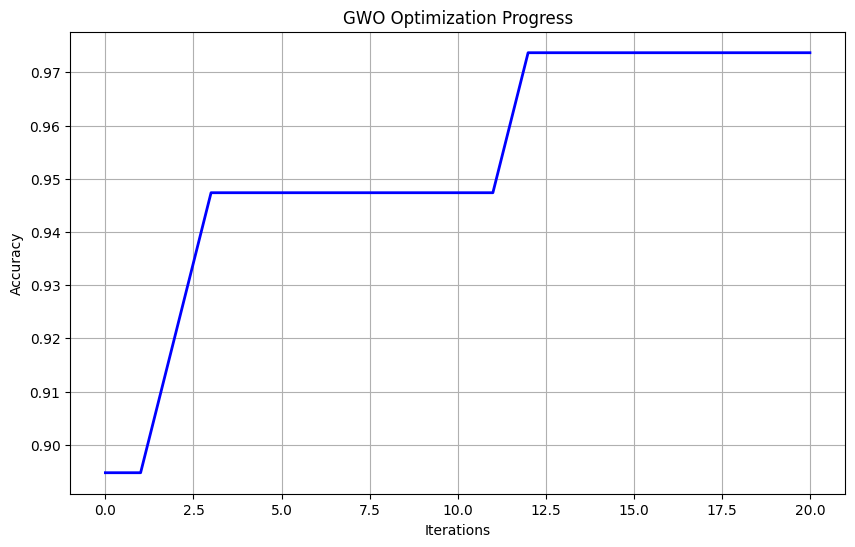

In [7]:
# --- 6) Plot optimization progress ---
plt.figure(figsize=(10, 6))
plt.plot(history['iterations'], history['best_fitness'], 'b-', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('GWO Optimization Progress')
plt.grid(True)
plt.savefig('gwo_optimization_progress.png')
plt.show()

## 7. Final Model Testing
Train and evaluate the final model using the best hyperparameters found.

In [8]:
# --- 7) Test final model on test data ---
print("\nTraining final model with best parameters...")
final_model = create_model(
    int(best_pos[0]), int(best_pos[1]), int(best_pos[2]), 
    best_pos[3], best_pos[4], int(best_pos[6]), int(best_pos[7])
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train, 
    epochs=int(best_pos[8]), 
    batch_size=int(best_pos[5]), 
    verbose=1,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

# Evaluate final model on test data
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal model accuracy on test data: {test_acc:.4f}")



Training final model with best parameters...
Epoch 1/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7606 - loss: 0.6381 - val_accuracy: 0.8421 - val_loss: 0.4727
Epoch 2/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8143 - loss: 0.4143 - val_accuracy: 0.8947 - val_loss: 0.3606
Epoch 3/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7690 - loss: 0.4320 - val_accuracy: 0.8421 - val_loss: 0.3393
Epoch 4/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8249 - loss: 0.3432 - val_accuracy: 0.8684 - val_loss: 0.3153
Epoch 5/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7523 - loss: 0.4196 - val_accuracy: 0.8947 - val_loss: 0.3275
Epoch 6/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8230 - loss: 0.3219 - val_accuracy: 0.9211 - val_loss: 0.2737
Epoch 7/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8484 - loss: 0.2899 - val_accuracy: 0.3421 - val_loss: 1.2402
Epoch 8/22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8377 - loss: 0.35

## 8. Training History Visualization
Plot the training history to visualize the model's learning progress.

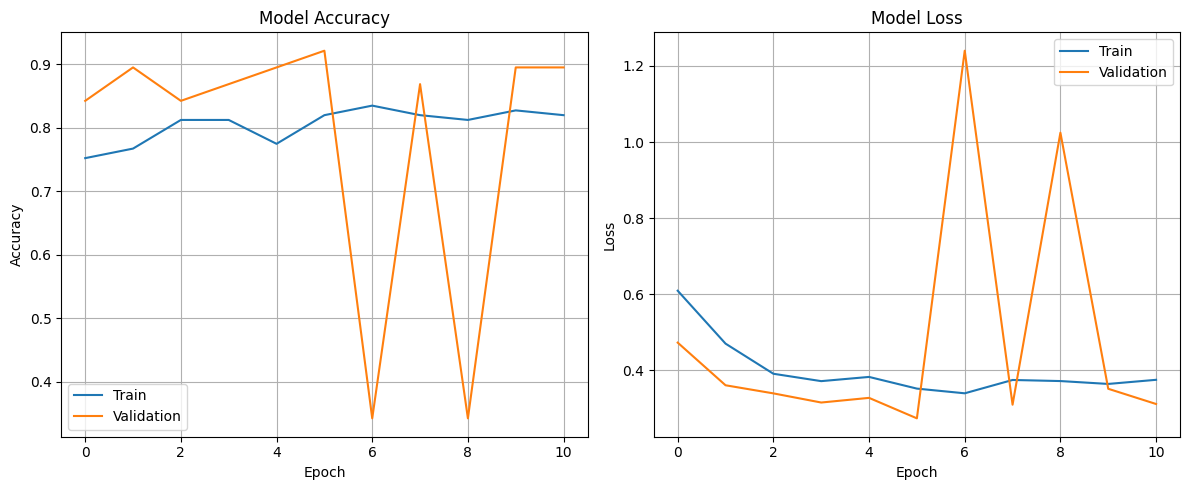

In [9]:
# --- 8) Plot final training history ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('final_model_training.png')
plt.show() 